## 🔗 Ringed Topology Routing Example

This notebook demonstrates how to design wind farm cable networks with a **ringed topology**in `OptiWindNet`, using `EWRouter`, `HGSRouter` and `MILPRouter`.

Rings, their capacity accounting and the redundancy they buy are described in [Ring semantics](../problem.md#ring-semantics). The same three topologies are solved with the Advanced API in [Network Topologies](lo29_topologies.ipynb).

### Load Data

In [1]:
from optiwindnet.api import WindFarmNetwork, EWRouter, HGSRouter, MILPRouter, ModelOptions, load_repository
%config InlineBackend.figure_formats = ['svg']

In [2]:
locations = load_repository()

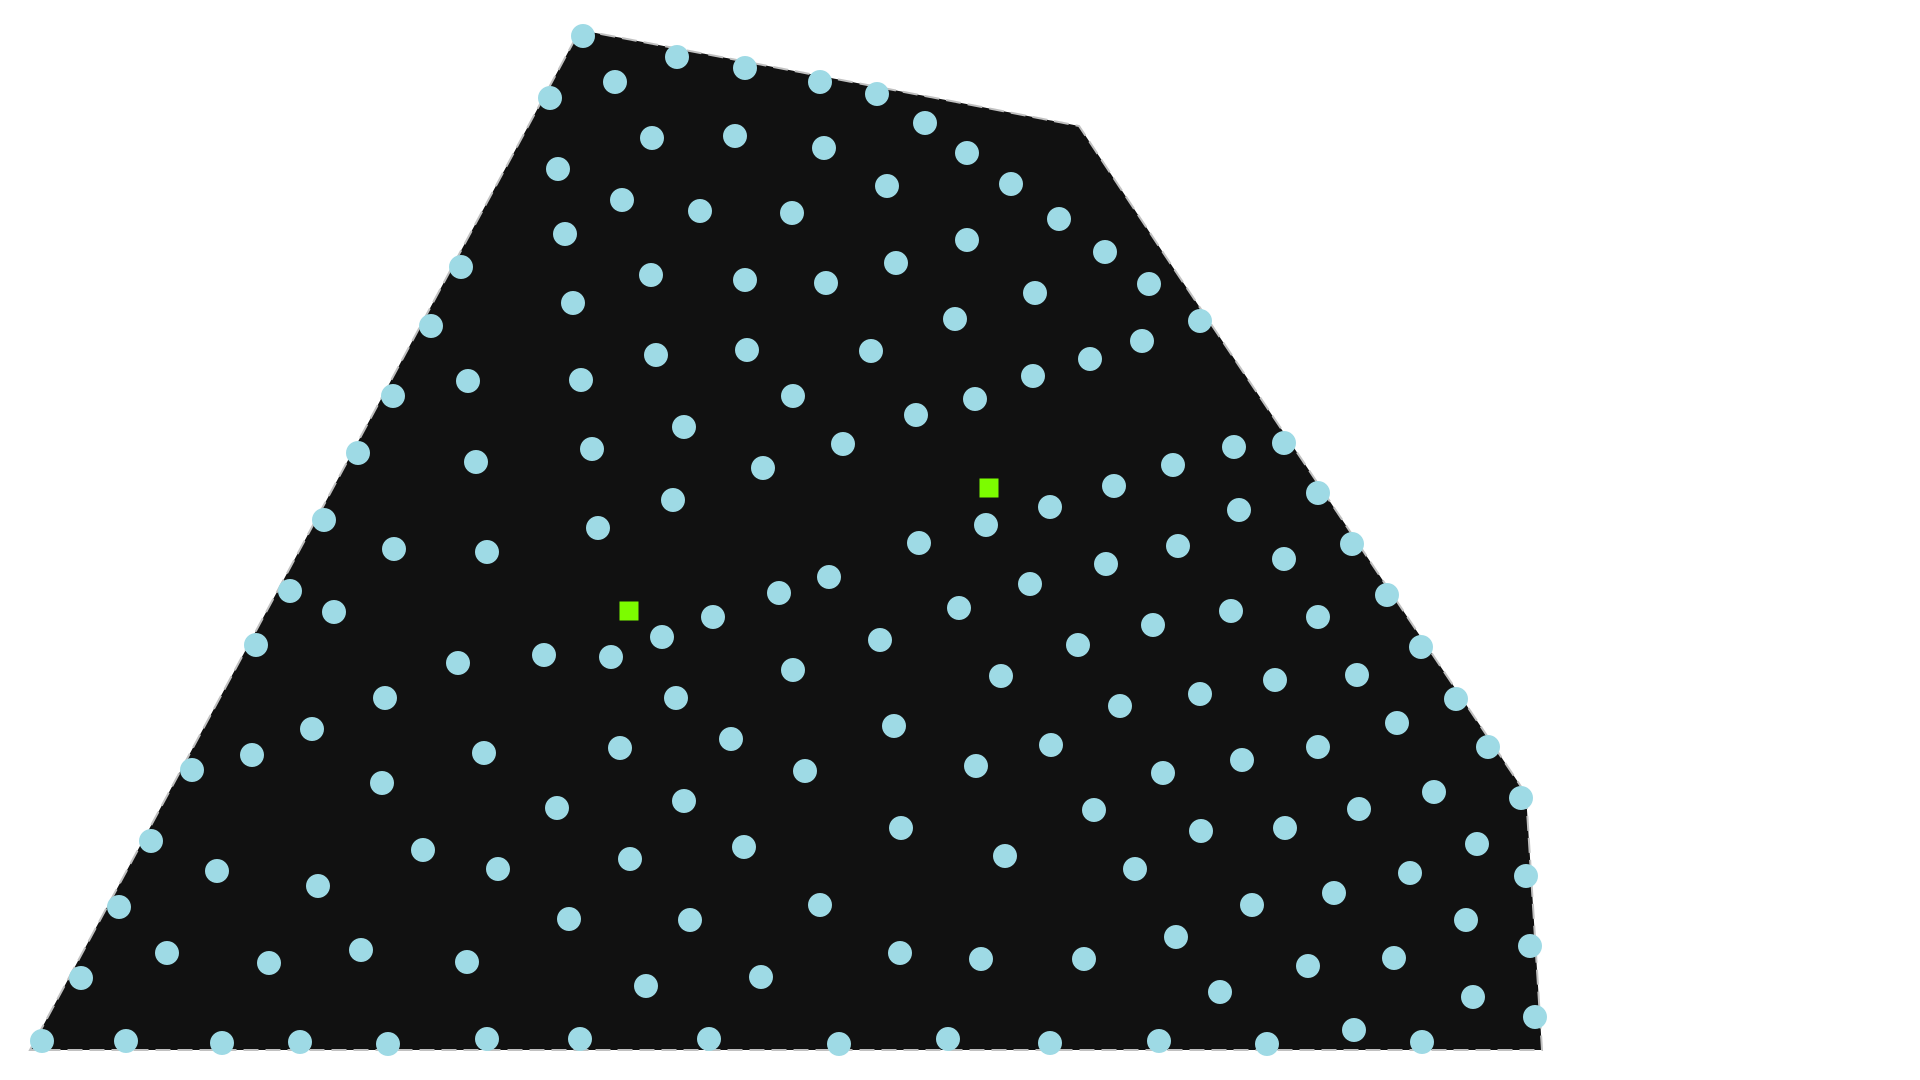

In [3]:
wfn = WindFarmNetwork(L=locations.borssele, cables=3)
wfn

### 1. Ringed Topology with EWRouter
`EWRouter` provides a constructive heuristic variant (`method='ringed'`) that forms closed loops.

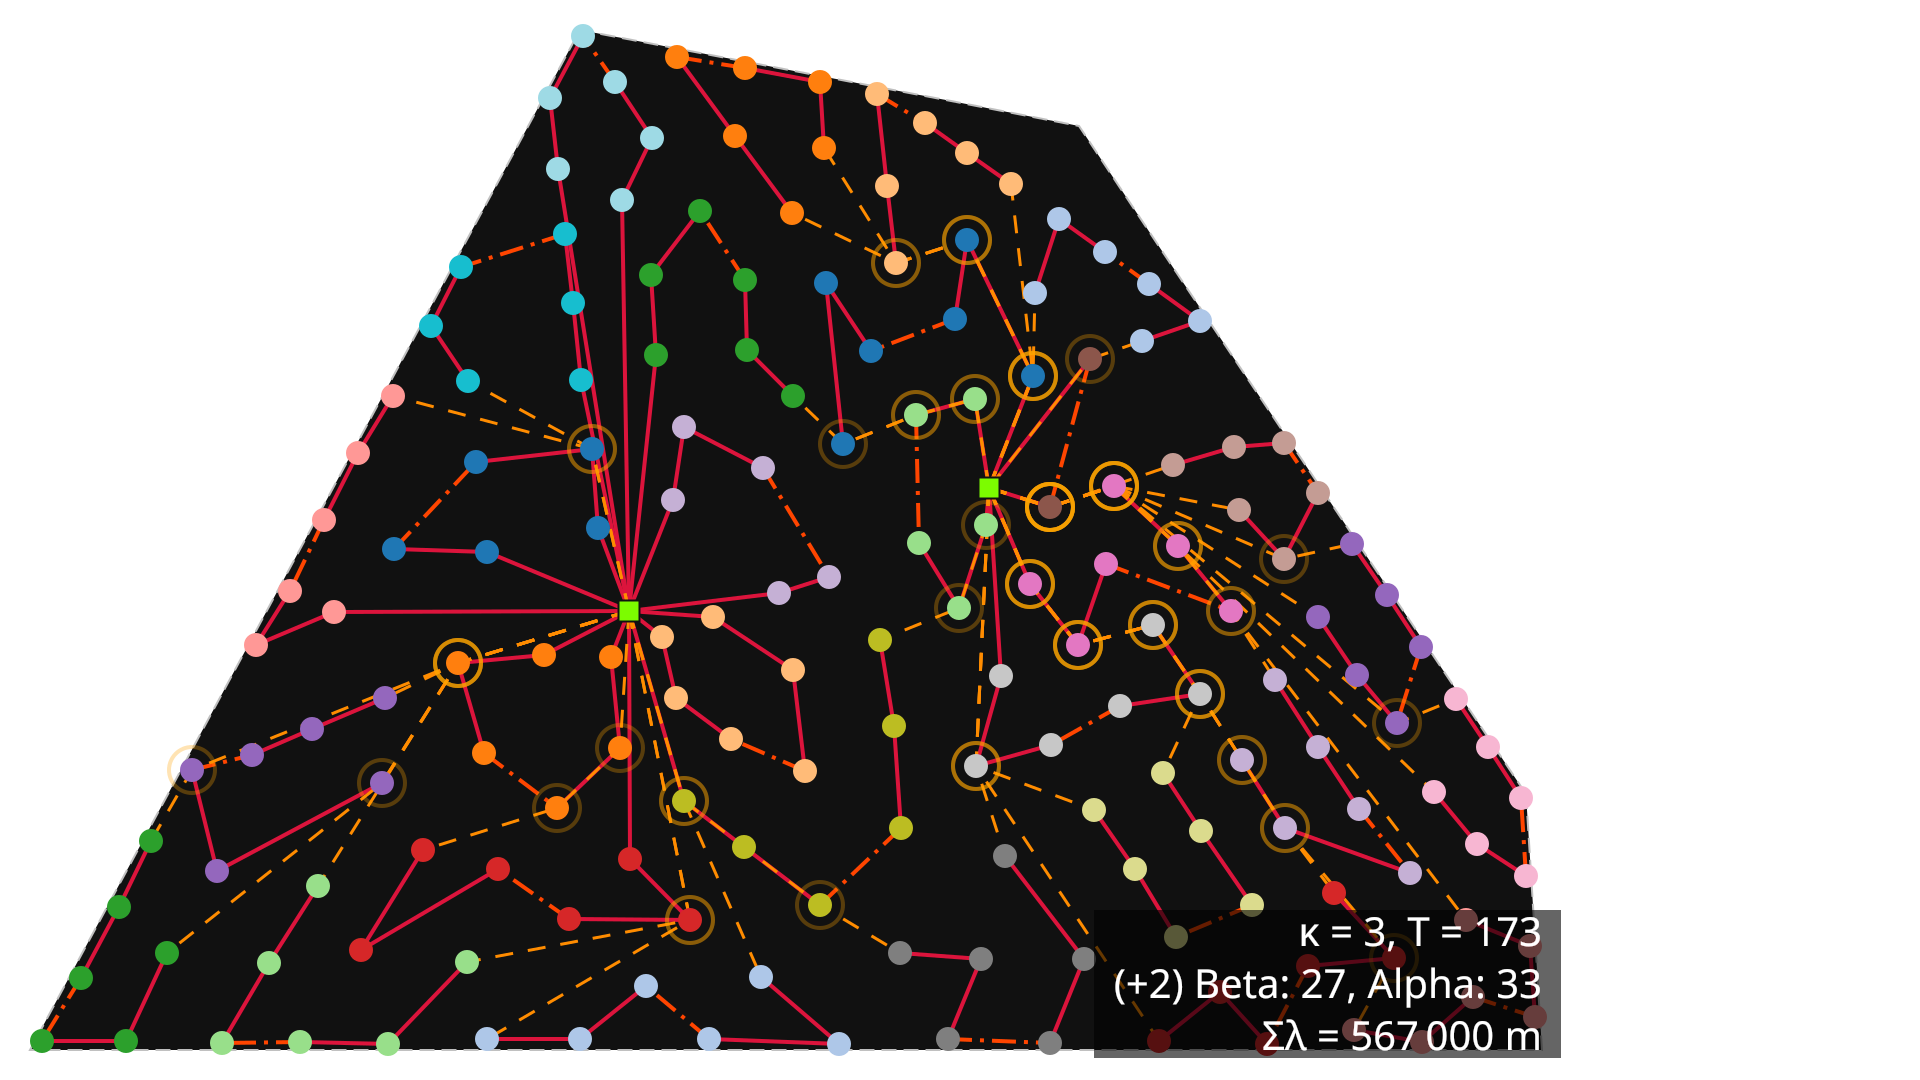

In [4]:
wfn.optimize(router=EWRouter(method='ringed'))
wfn

### 2. Ringed Topology with HGSRouter
`HGSRouter` supports `ringed=True` to solve a closed CVRP formulation using Hybrid Genetic Search.

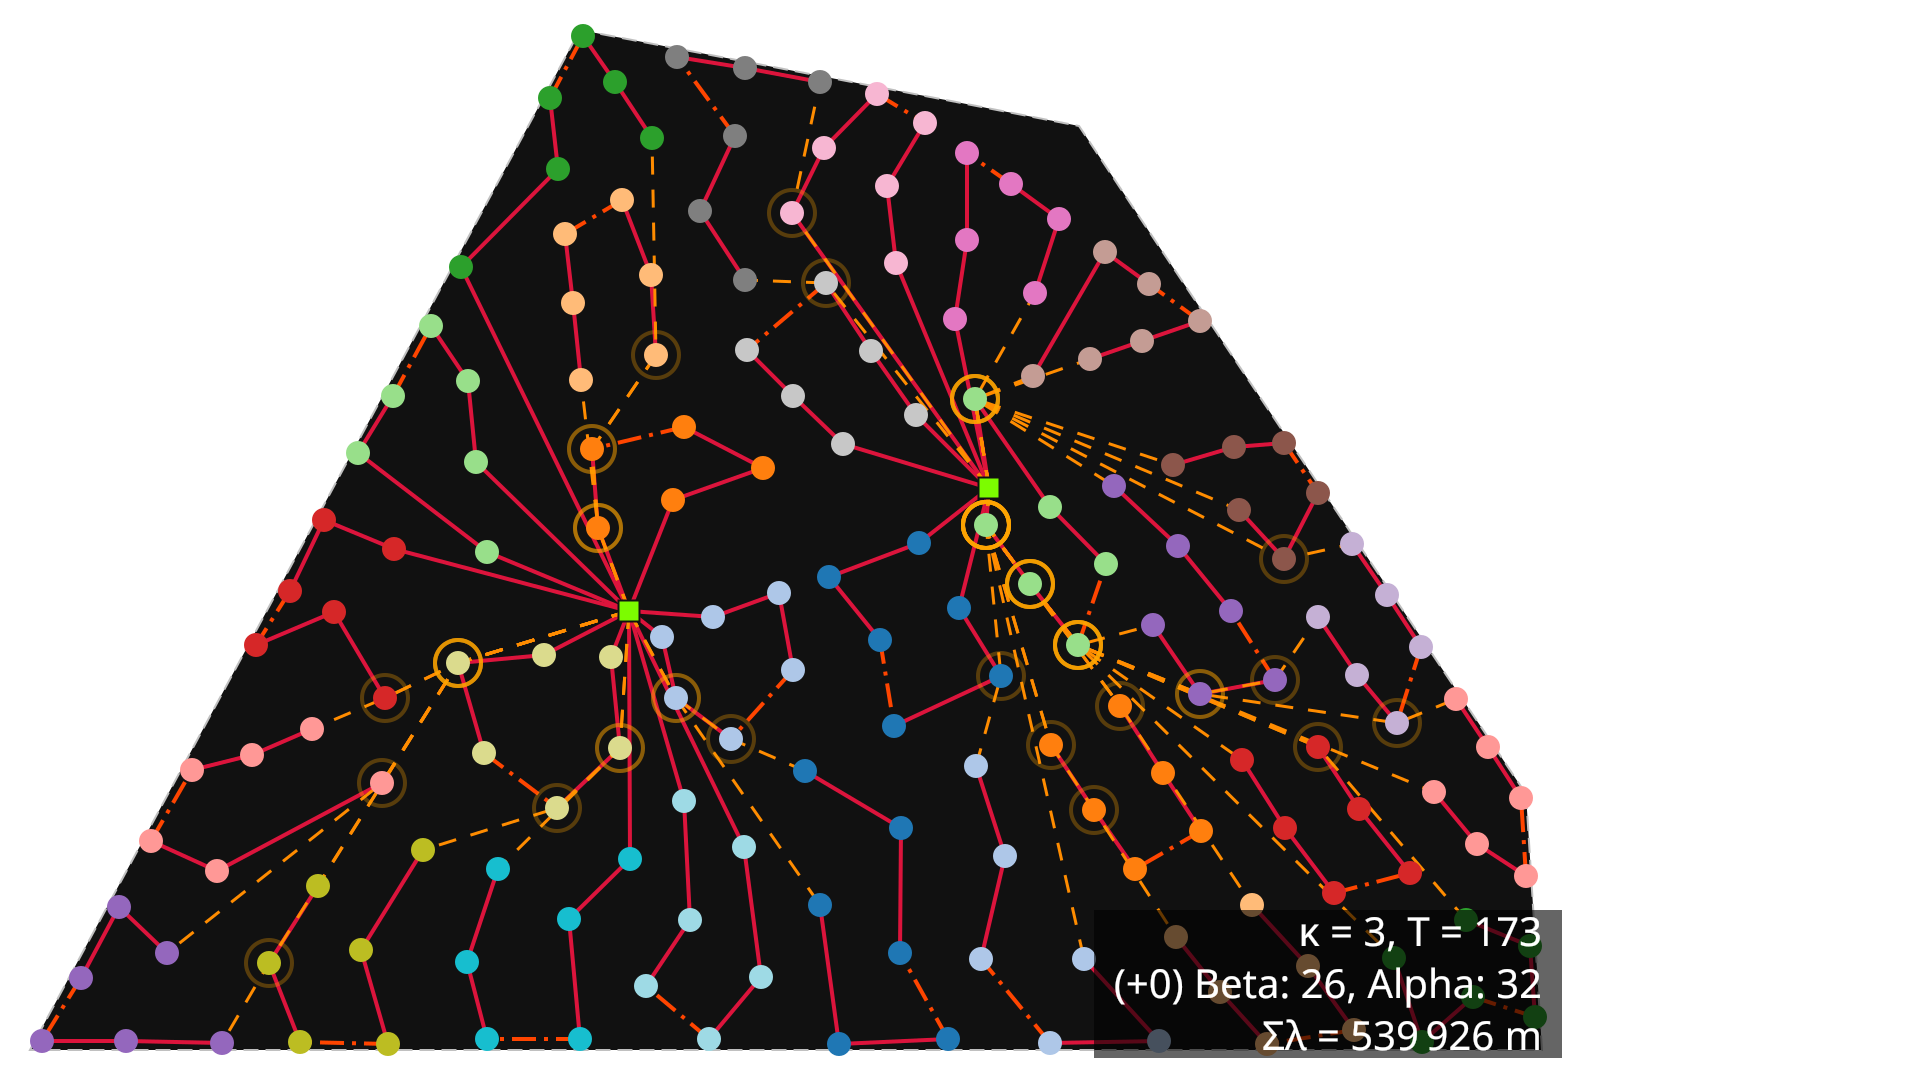

In [5]:
wfn.optimize(router=HGSRouter(ringed=True, time_limit=1.0))
wfn

### 3. Ringed Topology with MILPRouter
`MILPRouter` supports exact mathematical optimization of ringed networks by specifying `topology='ringed'` in `ModelOptions`.

In [6]:
router_milp = MILPRouter(
    solver_name='ortools.cp_sat',
    time_limit=90,
    mip_gap=0.005,
    model_options=ModelOptions(topology='ringed'),
    verbose=True,
)
wfn.optimize(router=router_milp)

IntegerBoundsPreprocessor                              6288 rows, 4438 columns, 23122 entries with magnitude in [1.000000e+00, 6.000000e+00]
BoundPropagationPreprocessor                           6288 rows, 4438 columns, 23122 entries with magnitude in [1.000000e+00, 6.000000e+00]
ImpliedIntegerPreprocessor                             6288 rows, 4438 columns, 23122 entries with magnitude in [1.000000e+00, 6.000000e+00]
IntegerBoundsPreprocessor                              6288 rows, 4438 columns, 23122 entries with magnitude in [1.000000e+00, 6.000000e+00]
ReduceCostOverExclusiveOrConstraintPreprocessor        6288 rows, 4438 columns, 23122 entries with magnitude in [1.000000e+00, 6.000000e+00]

Scaling to pure integer problem.
Num integers: 4438/4438 (implied: 0 in_inequalities: 0 max_scaling: 0) [IP] 
Maximum constraint coefficient relative error: 0
Maximum constraint worst-case activity error: 0
Constraint scaling factor range: [1, 1]

Starting CP-SAT solver v9.15.6755
Parameters: 

TerseLinks(scope='topology', topology='ringed', T=173, R=2, links=203)

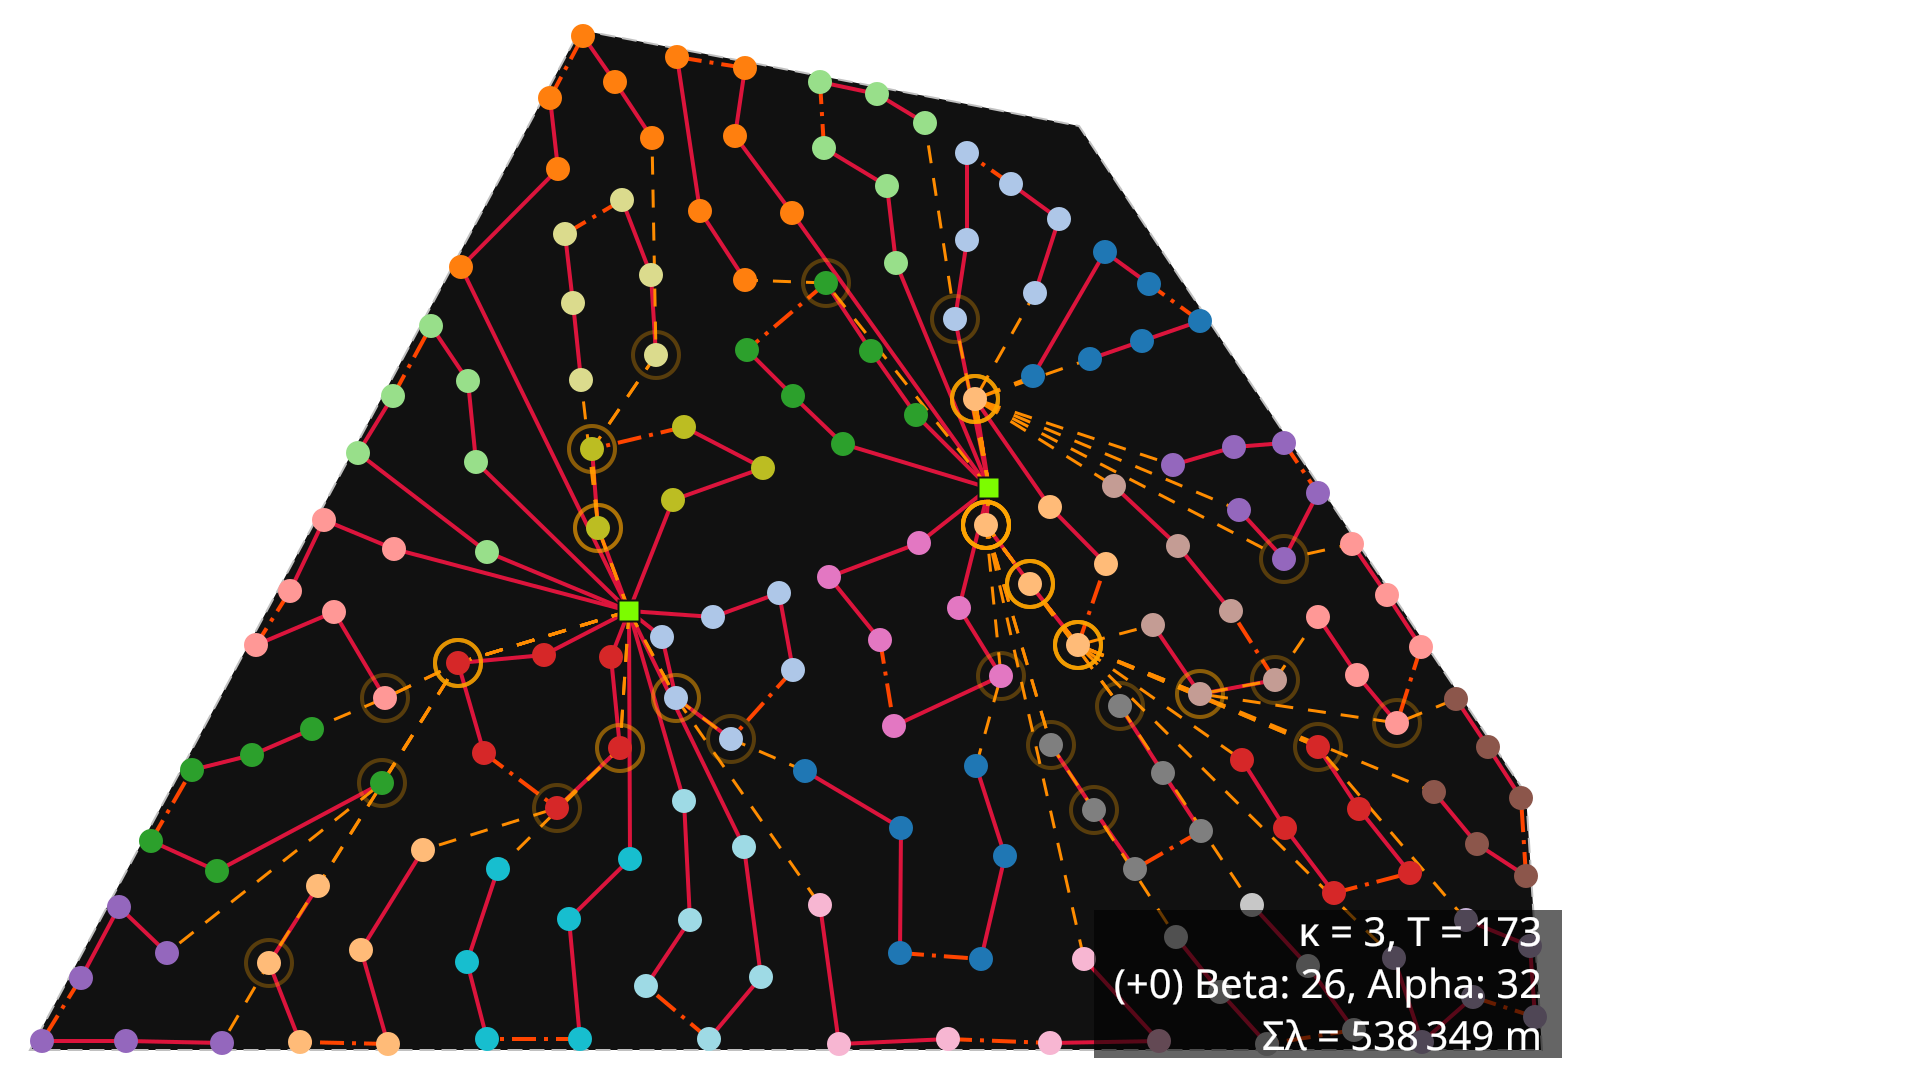

In [7]:
wfn